<a href="https://colab.research.google.com/github/aniketbaghel9040-cyber/NLP-Notes/blob/main/mdp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

optimal Policy:
{'Rainy': 'umbrella', 'cloudy': 'umbrella', 'sunny': 'no umbrella'}


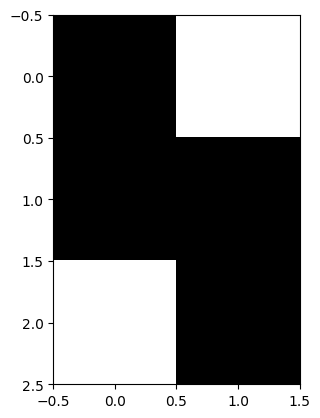

In [ ]:
states =['Rainy', 'cloudy', 'sunny']
action = ['umbrella','no umbrella']
rewards = {'Rainy':{'umbrella' :-1 ,'no umbrella':-5},
           'cloudy':{'umbrella' :-1 ,'no umbrella':-1},
           'sunny':{'umbrella' :-5 ,'no umbrella':-1}}
transition = {
    'Rainy':{'umbrella' :{ 'Rainy':0.7,'cloudy':0.3,'sunny':0}
                 ,'no umbrella':{ 'Rainy':0.3,'cloudy':0.4,'sunny':0.3} },

    'cloudy' : {'umbrella' :{ 'Rainy':0.4,'cloudy':0.6,'sunny':0}
                 ,'no umbrella':{ 'Rainy':0,'cloudy':0.7,'sunny':0.3} } ,

                'sunny':{'umbrella' :{ 'Rainy':0,'cloudy':0,'sunny':1}
                 ,'no umbrella':{ 'Rainy':0,'cloudy':0.4,'sunny':0.6} },

  }
discount_factor = 0.9
def value_iteration():
  V = {s: 0 for s in states}
  while True:
    new_V = {}
    for s in states:
      values = []
      for a in action: # Changed 'actions' to 'action'
        # Calculate the value for a given state s and action a
        action_value = rewards[s][a]
        for s2 in states:
          action_value += discount_factor * transition[s][a][s2]*V[s2]
        values.append(action_value)
      new_V[s]=max(values)

    # Check for convergence outside the inner loops
    if all (abs(V[s] - new_V[s])< 0.0001 for s in states):
      return new_V # Corrected 'new_v' to 'new_V'
    V = new_V # Update V for the next iteration

# The policy calculation and plotting should happen after value_iteration returns
# and typically outside the function itself, or in a separate function.
# Moving them out of the value_iteration loop and function for now.

# Call value iteration to get the optimal values
optimal_V = value_iteration()

policy ={}
for s in states:
  values =[]
  for a in action: # Changed 'actions' to 'action'
    value = rewards[s][a]
    for s2 in states:
      value += discount_factor * transition[s][a][s2]*optimal_V[s2] # Use optimal_V
    values.append(value)
  policy[s] = action[np.argmax(values)] # Use 'action' for indexing

print('optimal Policy:')
print(policy)

#plot
policy_values= np.zeros((len(states), len(action))) # Changed 'actions' to 'action'
for i ,s in enumerate(states):
  for j, a in enumerate(action): # Changed 'actions' to 'action'
    policy_values[i,j]= rewards[s][a] + discount_factor * sum(transition[s][a][s2] * optimal_V[s2] for s2 in states) # Corrected 'transtions' to 'transition' and used optimal_V

plt.imshow(policy_values , cmap = 'Greys')